# IoT Network Intrusion Detection — ACI-IoT-2023 Payload Dataset

This notebook trains a Random Forest classifier to detect and categorize network
attacks (DNS Flood, Port Scan, SYN Flood, etc.) from per-packet traffic features.

**Note:** an earlier version of this pipeline suffered from severe data leakage
(raw IPs, ports, timestamps, and packet payload were used as features), which
inflated accuracy to ~99.97% with meaningless metrics. This version removes
those columns and reflects genuine model performance.

## Imports

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

import os
import sys
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from scipy import sparse
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns

## Load the dataset

Loading the raw ACI-IoT-2023 payload CSV and inspecting its structure/columns
before any preprocessing.

In [2]:
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
df = pd.read_csv(project_root / 'data/raw/ACI-IoT-2023-Payload.csv')
pd.set_option('display.max_columns', None)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 631486 entries, 0 to 631485
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   srcip       631486 non-null  str  
 1   sport       631486 non-null  int64
 2   dstip       631486 non-null  str  
 3   dsport      631486 non-null  int64
 4   protocol_m  631486 non-null  str  
 5   sttl        631486 non-null  int64
 6   total_len   631486 non-null  int64
 7   payload     631486 non-null  str  
 8   stime       631486 non-null  int64
 9   label       631486 non-null  str  
dtypes: int64(5), str(5)
memory usage: 48.2 MB


In [3]:
df.head()

,srcip,sport,dstip,dsport,protocol_m,sttl,total_len,payload,stime,label
0,192.168.1.81,60683,239.255.255.250,1900,udp,2,362,4e4f54494659202a20485454502f312e310d0a4e54533a...,1698670981,Benign
1,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670984,Benign
2,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670985,Benign
3,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670986,Benign
4,192.168.1.9,53160,239.255.255.250,1900,udp,1,204,4d2d534541524348202a20485454502f312e310d0a484f...,1698670987,Benign


## Remove leakage-prone columns

`srcip`, `dstip`, `sport`, `dsport`, `stime`, and `payload` are dropped here.
These columns effectively identify *which capture session/attacker* a row came
from rather than describing general traffic behavior — keeping them let the
earlier model "cheat" by memorizing identity instead of learning attack
patterns. What remains (`protocol_m`, `sttl`, `total_len`) are the only
features used for classification.

In [4]:
df = df.drop(columns=["srcip", "sport", "dstip", "dsport", "stime", "payload"])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 631486 entries, 0 to 631485
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   protocol_m  631486 non-null  str  
 1   sttl        631486 non-null  int64
 2   total_len   631486 non-null  int64
 3   label       631486 non-null  str  
dtypes: int64(2), str(2)
memory usage: 19.3 MB


In [6]:
df["protocol_m"].value_counts()

protocol_m
tcp      523628
udp      105235
other      2623
Name: count, dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 631486 entries, 0 to 631485
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   protocol_m  631486 non-null  str  
 1   sttl        631486 non-null  int64
 2   total_len   631486 non-null  int64
 3   label       631486 non-null  str  
dtypes: int64(2), str(2)
memory usage: 19.3 MB


## Define features (X) and target (y)

`label` is the target — the attack type (or Benign) for each row. Everything
else is the feature set the model will learn from.

In [8]:
X = df.drop('label', axis=1)
y = df['label']

## Train/test split (stratified)

`stratify=y` ensures every class — including rare ones like UDP Flood (only
~68 total rows) — keeps roughly the same proportion in both the train and test
sets. Without this, a random split risks a rare class ending up almost
entirely in one side, which would break both training and evaluation.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 505188 entries, 277174 to 305332
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   protocol_m  505188 non-null  str  
 1   sttl        505188 non-null  int64
 2   total_len   505188 non-null  int64
dtypes: int64(2), str(1)
memory usage: 15.4 MB


## Preprocessing: encode categorical, scale numeric

`protocol_m` (categorical) is one-hot encoded. `sttl` and `total_len`
(numeric) are standardized with `StandardScaler`. Using the right transform
per column type — instead of one-hot encoding everything — avoids blowing up
dimensionality and preserves the numeric meaning of `sttl`/`total_len`.

In [11]:
from sklearn.compose import ColumnTransformer

x_preprocessor = ColumnTransformer(
    transformers=[
        ("one_hot", OneHotEncoder(sparse_output=False), ["protocol_m"]),
        ("scale", StandardScaler(), ["sttl", "total_len"]),
    ])

## Fit on train only, transform test separately

`fit_transform` is called only on `X_train`. `X_test` is transformed using
the *already-fitted* preprocessor (`.transform`, not `.fit_transform`). This
is critical: fitting on the full dataset (including test rows) before
splitting would let information from the test set leak into preprocessing —
a subtler form of the leakage problem described above.

In [12]:
X_train_encoded = x_preprocessor.fit_transform(X_train)
X_test_encoded = x_preprocessor.transform(X_test)

## Encode the target labels

`LabelEncoder` is used here rather than one-hot/multi-label encoding, since
this is a single-label, multiclass problem (each row belongs to exactly one
category). As with the feature preprocessor, it's fit on `y_train` only and
applied to `y_test` with `.transform`, so both sets share the same
label-to-integer mapping.

In [13]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [14]:
X_train_encoded.shape, X_test_encoded.shape

((505188, 5), (126298, 5))

In [15]:
y_train_encoded.shape, y_test_encoded.shape

((505188,), (126298,))

In [16]:
print(y_train_encoded)

[0 0 0 ... 0 0 0]


## Class weighting to handle severe imbalance

Benign traffic (~601K rows) vastly outnumbers rare attack types like UDP
Flood (~68 rows) or ICMP Flood. Training without any weighting caused the
model to almost completely ignore rare classes (high accuracy, but near-zero
recall on them).

Full inverse-frequency weighting (`class_weight="balanced"`) overcorrected —
it caught far more rare-class attacks but also triggered a large number of
false alarms on Benign traffic, hurting precision and overall F1.

The weights below use a **square-root-scaled** inverse frequency instead of
the raw ratio — a middle ground that improves recall on rare classes without
over-flagging normal traffic as an attack.

In [17]:
class_counts = pd.Series(y_train_encoded).value_counts()

majority_count = class_counts.max()

class_weights = {
    cls: np.sqrt(majority_count / count)
    for cls, count in class_counts.items()
}

print(class_weights)

{0: np.float64(1.0), 1: np.float64(5.6918941010714414), 2: np.float64(11.383022313340446), 7: np.float64(14.226504933501792), 6: np.float64(16.879208876831054), 5: np.float64(32.14418963107682), 9: np.float64(36.77650385715119), 4: np.float64(62.06409590093132), 8: np.float64(94.4275148225111), 3: np.float64(102.30963234009405)}


## Train the Random Forest

`n_estimators=300` for a more stable ensemble, with the sqrt-scaled class
weights above applied per class.

In [18]:
from sklearn.ensemble import RandomForestClassifier

model_RFC = RandomForestClassifier(class_weight=class_weights, n_estimators=300, random_state=42)
model_RFC.fit(X_train_encoded, y_train_encoded)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{0: np.float64(1.0), 1: np.float64(5.6918941010714414), 2: np.float64(11.383022313340446), 3: np.float64(102.30963234009405), ...}"
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_featu

In [19]:
y_pred = model_RFC.predict(X_test_encoded)

## Evaluate: classification report

Accuracy alone is misleading here given the class imbalance — Benign traffic
dominates the test set, so even a poor model can score high on raw accuracy.
**Macro avg** (unweighted average across classes) is the more honest measure
of how well rare attack types are detected; **weighted avg** is skewed
toward Benign's large sample count.

In [20]:
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy}")

# Print classification report
print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=le.classes_
))

Accuracy: 0.9898018971005084
                    precision    recall  f1-score   support

            Benign       1.00      0.99      0.99    120374
         DNS Flood       0.99      0.98      0.99      3715
 Dictionary Attack       0.93      1.00      0.97       929
        ICMP Flood       1.00      1.00      1.00        12
           OS Scan       0.16      0.65      0.25        31
         Port Scan       0.30      0.73      0.43       116
         SYN Flood       1.00      1.00      1.00       423
         Slowloris       0.92      1.00      0.96       595
         UDP Flood       0.01      0.29      0.02        14
Vulnerability Scan       0.13      0.63      0.21        89

          accuracy                           0.99    126298
         macro avg       0.64      0.83      0.68    126298
      weighted avg       1.00      0.99      0.99    126298



## Evaluate: confusion matrix

Rows = true label, columns = predicted label. The diagonal shows correct
predictions; off-diagonal cells show what the model confuses. Most
misclassifications here are rare attacks (Port Scan, OS Scan, UDP Flood,
Vulnerability Scan) being predicted as Benign or vice versa — consistent with
these attacks being defined by *patterns across multiple packets* rather than
any single packet's protocol/TTL/length, which this feature set can't fully
capture.

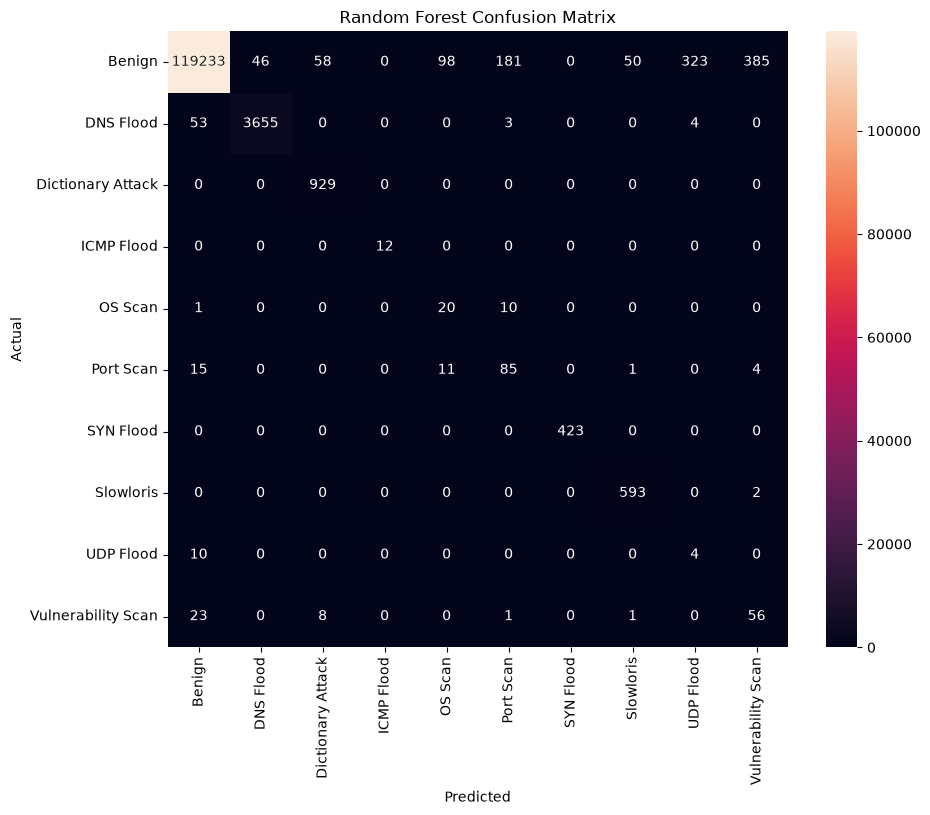

In [21]:
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

## Limitations & Future Work

**What works well:** the model reliably detects Dictionary Attack, SYN
Flood, Slowloris, DNS Flood, and ICMP Flood — classes with either large
sample counts, distinctive protocol/TTL/length signatures, or both.

**What doesn't work well:** Port Scan, OS Scan, Vulnerability Scan, and
especially UDP Flood remain hard to classify precisely (precision as low as
0.01–0.30 for these), despite class-weight tuning. Two compounding causes:

1. **Feature limitation.** Only per-packet features (`protocol_m`, `sttl`,
   `total_len`) are used. Scans and floods are fundamentally
   *cross-packet* behaviors — e.g. one source contacting many distinct
   destination ports in a short window, or an unusually high packet rate —
   which no single packet's protocol/TTL/length can capture on its own.
2. **Extreme class imbalance.** Some attack types have only a few dozen to
   a few hundred training examples (e.g. UDP Flood: ~68 total rows before
   the split), leaving very little for the model to generalize from
   regardless of weighting strategy.

**What was tried for class imbalance**, in order:
- No weighting → high accuracy (99.7%) but very low recall on rare classes
  (as low as 0.07 for UDP Flood) — the model largely ignored them.
- `class_weight="balanced"` / `"balanced_subsample"` → recall on rare
  classes rose sharply (up to 0.90 macro recall), but precision collapsed
  (macro precision ~0.61) due to a large increase in false positives on
  Benign traffic — full inverse-frequency weighting overcorrected.
- **Square-root-scaled class weights** (final model) → the best balance
  found: macro recall 0.83, macro precision 0.64, with far fewer false
  alarms than full balancing. This is the version reported above.

**Future work:**
- **Add flow-level features** (e.g. packets/sec from a source, number of
  distinct destination ports contacted in a time window, connection
  duration) from the companion `ACI-IoT-2023.csv` dataset — this is
  expected to give the largest improvement for scan/flood detection,
  since these attacks are defined by behavior over time, not by any single
  packet.
- **Try a two-stage model**: a binary Benign-vs-Attack classifier tuned
  for high precision, followed by a second classifier (only run on
  flagged "Attack" rows) to determine attack type. This separates "avoid
  false alarms on Benign traffic" from "distinguish attack types," which
  are currently being forced into a single 10-way classifier.
- **Constrain tree depth / `min_samples_leaf`** to test whether the low
  precision on rare classes is partly due to overly specific splits
  learned from very few examples.
- **Collect more samples** for the rarest classes (UDP Flood, OS Scan) if
  more traffic captures become available, since 14–31 examples is a hard
  floor for any model to learn from reliably.

## Save the trained model

The trained model, preprocessor, and label encoder are bundled together with
`joblib` so inference later only needs a single file load, with no retraining
required.

In [23]:
import joblib

joblib.dump({
    "model": model_RFC,
    "preprocessor": x_preprocessor,
    "label_encoder": le
}, project_root / "models/RFCmodelbundle.joblib")

['K:\\Projects\\Machine Learning\\aci-iot-network-traffic\\models\\RFCmodelbundle.joblib']